In [1]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017")
print(client.list_database_names())

db = client['worldCup']
print(db.list_collection_names())        

coll = db['matches']
doc = coll.find_one()
print(doc)                               

['admin', 'config', 'local', 'worldCup']
['matches']
{'_id': ObjectId('69d666c79fdb7a6388ecfda0'), 'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 13, 0, 0), 'home_team': 'France', 'away_team': 'Mexico', 'home_score': 4, 'away_score': 1, 'venue': 'Estadio Pocitos, Montevideo', 'winner': 'France'}


In [2]:
datos = list(coll.find(
    {},
    {
    "_id": 0,
    "home_team": 1,
    "away_team": 1,
    "tournament": 1,
    "stage": 1,
    "date": 1,
    "home_score": 1,
    "away_score": 1,
    "venue": 1,
    "elo_diff": 1,
    "winner": 1,
    "home_days_since_last_match": 1,
    "away_days_since_last_match": 1
    }
))
print(datos)

[{'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 13, 0, 0), 'home_team': 'France', 'away_team': 'Mexico', 'home_score': 4, 'away_score': 1, 'venue': 'Estadio Pocitos, Montevideo', 'winner': 'France'}, {'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 15, 0, 0), 'home_team': 'Argentina', 'away_team': 'France', 'home_score': 1, 'away_score': 0, 'venue': 'Estadio Parque Central, Montevideo', 'winner': 'Argentina'}, {'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 16, 0, 0), 'home_team': 'Chile', 'away_team': 'Mexico', 'home_score': 3, 'away_score': 0, 'venue': 'Estadio Parque Central, Montevideo', 'winner': 'Chile'}, {'tournament': '1930--uruguay', 'stage': 'Group 1', 'date': datetime.datetime(1930, 7, 19, 0, 0), 'home_team': 'Chile', 'away_team': 'France', 'home_score': 1, 'away_score': 0, 'venue': 'Estadio Centenario, Montevideo', 'winner': 'Chile'}, {'tournament': '1930--ur

Hay que armar cada unas de las columnas y tambien extraer sus datos

In [3]:
# Usamos .get(campo, "Unknown") para que si falta el dato, no explote el código
home_team = le_team.fit_transform([d.get("home_team", "Unknown") for d in datos])
away_team = le_team.fit_transform([d.get("away_team", "Unknown") for d in datos])
tournament = le_tournament.fit_transform([d.get("tournament", "Unknown") for d in datos])

# Aquí estaba el fallo del KeyError
stage = le_stage.fit_transform([d.get("stage", "Unknown") for d in datos])

y = le_winner.fit_transform([d.get("winner", "Unknown") for d in datos])

# Para los valores numéricos como elo_diff, si no existen ponemos 0
X = np.column_stack([
    home_team,
    away_team,
    tournament,
    stage,
    [d.get("elo_diff", 0) for d in datos],
    [d.get("home_days_since_last_match", 0) if d.get("home_days_since_last_match") is not None else 0 for d in datos],
    [d.get("away_days_since_last_match", 0) if d.get("away_days_since_last_match") is not None else 0 for d in datos]
])

Predicción real

In [40]:
print("team mapping:", dict(zip(le_team.classes_, le_team.transform(le_team.classes_))))
print("winner classes:", le_winner.classes_)
import numpy as np
print("y counts:", np.bincount(y))

team mapping: {np.str_('Algeria'): np.int64(0), np.str_('Angola'): np.int64(1), np.str_('Argentina'): np.int64(2), np.str_('Australia'): np.int64(3), np.str_('Austria'): np.int64(4), np.str_('Belgium'): np.int64(5), np.str_('Bolivia'): np.int64(6), np.str_('Bosnia-Herzegovina'): np.int64(7), np.str_('Brazil'): np.int64(8), np.str_('Bulgaria'): np.int64(9), np.str_('Cameroon'): np.int64(10), np.str_('Canada'): np.int64(11), np.str_('Chile'): np.int64(12), np.str_('China'): np.int64(13), np.str_('Colombia'): np.int64(14), np.str_('Costa Rica'): np.int64(15), np.str_('Croatia'): np.int64(16), np.str_('Cuba'): np.int64(17), np.str_('Czech Republic'): np.int64(18), np.str_('Czechoslovakia'): np.int64(19), np.str_("Côte d'Ivoire"): np.int64(20), np.str_('Denmark'): np.int64(21), np.str_('Dutch East Indies'): np.int64(22), np.str_('East Germany'): np.int64(23), np.str_('Ecuador'): np.int64(24), np.str_('Egypt'): np.int64(25), np.str_('El Salvador'): np.int64(26), np.str_('England'): np.int64(

BLOQUE MACHINE LEARNING


In [13]:
from pymongo import MongoClient
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# --- A. CONEXIÓN Y CARGA ---
client = MongoClient("mongodb://localhost:27017/")
db = client["worldCup"] 
coll = db["matches"]
datos = list(coll.find({}, {"_id": 0}))

# --- B. LIMPIEZA CRÍTICA (Arreglamos las horas en el ganador) ---
for d in datos:
    # Si 'winner' es "13:00 France", esto lo convierte en "France"
    win_val = str(d.get("winner", "Draw"))
    d["winner_clean"] = win_val.split()[-1] if " " in win_val else win_val

# Convertimos a DataFrame de Pandas para manejarlo mejor
df = pd.DataFrame(datos)

# --- C. TRANSFORMACIÓN A NÚMEROS (Label Encoding) ---
le_team = LabelEncoder()
le_winner = LabelEncoder()

# Ajustamos los nombres de equipos (unimos local y visitante para que el número sea el mismo)
todos_los_equipos = pd.concat([df['home_team'], df['away_team']]).unique()
le_team.fit(todos_los_equipos)

# Creamos las columnas numéricas
df['home_idx'] = le_team.transform(df['home_team'])
df['away_idx'] = le_team.transform(df['away_team'])
df['target'] = le_winner.fit_transform(df['winner_clean'])

# --- D. ENTRENAMIENTO ---
# Seleccionamos las columnas que realmente ayudan a predecir
# Usamos elo_diff que es la clave de vuestro proyecto
columnas_x = ['home_idx', 'away_idx', 'elo_diff']
X = df[columnas_x].fillna(0)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- E. RESULTADO ---
y_pred = model.predict(X_test)
print(f"Logrado: Partidos procesados: {len(df)}")
print(f"Precisión del modelo: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Logrado: Partidos procesados: 1896
Precisión del modelo: 51.32%


In [9]:
from sklearn.ensemble import RandomForestRegressor

# Entrenamos dos modelos: uno para goles locales y otro para visitantes
model_goals_home = RandomForestRegressor().fit(X_train, df.loc[X_train.index, 'home_score'])
model_goals_away = RandomForestRegressor().fit(X_train, df.loc[X_train.index, 'away_score'])

def predecir_marcador(local, visitante):
    h = le_team.transform([local])[0]
    a = le_team.transform([visitante])[0]
    # Usamos elo_diff = 0 por defecto si no lo tenemos
    input_data = np.array([[h, a, 0]]) 
    
    goles_h = model_goals_home.predict(input_data)[0]
    goles_a = model_goals_away.predict(input_data)[0]
    
    print(f"Predicción marcador: {local} {goles_h:.1f} - {goles_a:.1f} {visitante}")

predecir_marcador("Spain", "Germany")

Predicción marcador: Spain 1.0 - 1.2 Germany


/Users/macbookpro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/macbookpro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


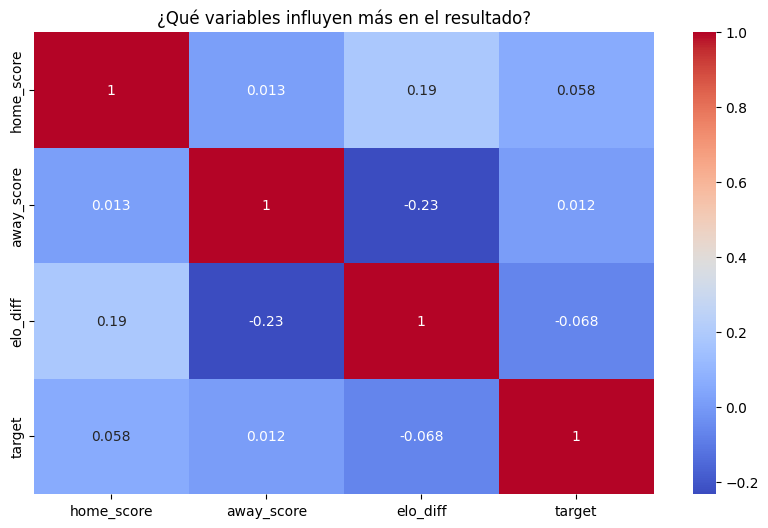

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df[['home_score', 'away_score', 'elo_diff', 'target']].corr(), annot=True, cmap='coolwarm')
plt.title("¿Qué variables influyen más en el resultado?")
plt.show()

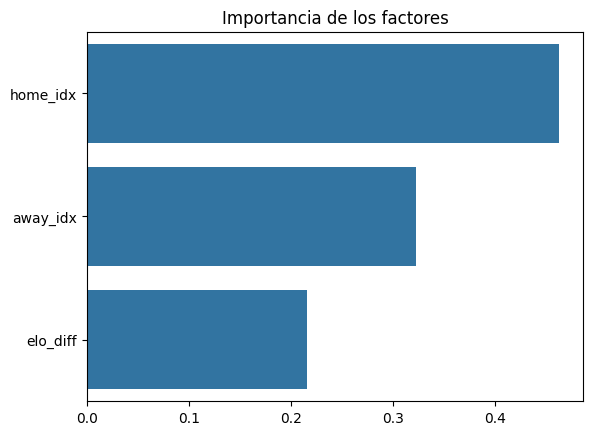

In [15]:
importances = model.feature_importances_
features = columnas_x
sns.barplot(x=importances, y=features)
plt.title("Importancia de los factores")
plt.show()

# CORRELACIÓN RESULTADOS DEL ENCUENTRO - ALTITUD

Obteniendo altitudes reales para 226 sedes únicas...
Precisión real con Altitud Geográfica: 61.58%


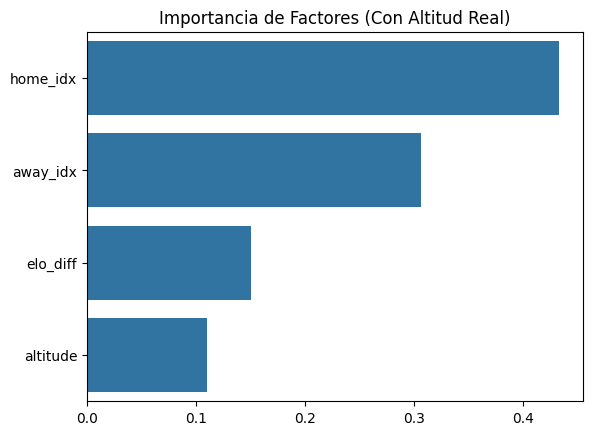

In [ ]:
import pandas as pd
import numpy as np
from pymongo import MongoClient
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# CONEXIÓN 
client = MongoClient("mongodb://localhost:27017/")
db = client["worldCup"] 
coll = db["matches"]
datos = list(coll.find({}, {"_id": 0}))
df = pd.DataFrame(datos)

# LIMPIEZA 
def limpiar_nombre(nombre):
    n = str(nombre)
    return n.split()[-1] if " " in n else n

df['home_team'] = df['home_team'].apply(limpiar_nombre)
df['away_team'] = df['away_team'].apply(limpiar_nombre)
df['winner'] = df['winner'].fillna('Draw').apply(limpiar_nombre)

# ALTITUD AUTOMÁTICA 
geolocator = Nominatim(user_agent="world_cup_predictor")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# Sacamos las sedes únicas para no preguntar 2000 veces lo mismo a internet
sedes_unicas = df['venue'].unique()
mapeo_altitudes = {}

print(f"Obteniendo altitudes reales para {len(sedes_unicas)} sedes únicas...")

for sede in sedes_unicas:
    try:
        # Paso 1: Buscar coordenadas de la sede 
        location = geolocator.geocode(sede)
        if location:
            # Paso 2: Consultar altitud real por GPS usando Open-Elevation
            url = f"https://api.open-elevation.com/api/v1/lookup?locations={location.latitude},{location.longitude}"
            response = requests.get(url).json()
            altitud = response['results'][0]['elevation']
            mapeo_altitudes[sede] = altitud
        else:
            mapeo_altitudes[sede] = 50 # Valor por defecto si no encuentra la calle/estadio
    except:
        mapeo_altitudes[sede] = 50

# Aplicamos los datos reales a la columna del DataFrame
df['altitude'] = df['venue'].map(mapeo_altitudes)

# TRANSFORMACIÓN ---
le_team = LabelEncoder()
le_winner = LabelEncoder()
todos_equipos = pd.concat([df['home_team'], df['away_team']]).unique()
le_team.fit(todos_equipos)

df['home_idx'] = le_team.transform(df['home_team'])
df['away_idx'] = le_team.transform(df['away_team'])
df['target'] = le_winner.fit_transform(df['winner'])

# ENTRENAMIENTO ---
columnas_x = ['home_idx', 'away_idx', 'elo_diff', 'altitude']
X = df[columnas_x].fillna(0)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_win = RandomForestClassifier(n_estimators=100, random_state=42)
model_win.fit(X_train, y_train)

# RESULTADOS 
y_pred = model_win.predict(X_test)
print(f"Precisión real con Altitud Geográfica: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Gráfica de Importancia actualizada
importances = model_win.feature_importances_
sns.barplot(x=importances, y=columnas_x)
plt.title("Importancia de Factores (Con Altitud Real)")
plt.show()

## CORRELACIÓN CLIMA DEL PARTIDO - RESULTADO DEL ENCUENTRO 

In [5]:
# Convertimos la fecha a formato de tiempo real
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month # Extraemos el mes para el "clima habitual"

Obtenemos el clima real de cada partido con la API

¿Qué temparatura hace de media en cada país durante los meses del mundial (junio-julio)?

In [ ]:
import pandas as pd
from pymongo import MongoClient
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import openmeteo_requests
import requests_cache
from retry_requests import retry
import time

# CONFIGURACIÓN DE APIS Y CACHÉ ---
# Guardamos los datos en caché para no repetir peticiones a internet
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Configuramos el GPS con paciencia (2 segundos entre búsquedas)
geolocator = Nominatim(user_agent="world_cup_final_research_jaime", timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=2.0, error_wait_seconds=5.0)

# CONEXIÓN Y LIMPIEZA INICIAL ---
client = MongoClient("mongodb://localhost:27017/")
db = client["worldCup"] 
df = pd.DataFrame(list(db["matches"].find({}, {"_id": 0})))

# 1. Convertimos a fecha y ELIMINAMOS las que estén vacías (evita el error NaT)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date']) 

# FUNCIONES DE APOYO ---
def limpiar_nombre_geografico(nombre):
    """Quita horas y ruidos de los nombres (ej: '20:30 France' -> 'France')"""
    n = str(nombre).strip()
    return n.split()[-1] if " " in n else n

memo_coords = {}

def get_coords(name):
    """Busca coordenadas GPS evitando repetir búsquedas ya hechas."""
    nombre_limpio = limpiar_nombre_geografico(name)
    if nombre_limpio in memo_coords: return memo_coords[nombre_limpio]
    
    try:
        loc = geocode(nombre_limpio)
        if loc:
            memo_coords[nombre_limpio] = (loc.latitude, loc.longitude)
            return memo_coords[nombre_limpio]
    except:
        pass
    return (0, 0)

def get_weather_data(lat, lon, date):
    """Consulta el clima histórico en la API de Open-Meteo."""
    # Si las coordenadas fallaron o la fecha es nula, devolvemos valores neutros
    if lat == 0 or pd.isnull(date): 
        return 22.0, 50.0, 10.0
    
    try:
        date_str = date.strftime('%Y-%m-%d')
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat, "longitude": lon,
            "start_date": date_str, "end_date": date_str,
            "daily": ["apparent_temperature_max", "relative_humidity_2m_max", "wind_speed_10m_max"]
        }
        responses = openmeteo.weather_api(url, params=params)
        res = responses[0].Daily()
        # Orden: Temperatura Aparente, Humedad, Viento
        return (res.Variables(0).ValuesAsNumpy()[0], 
                res.Variables(1).ValuesAsNumpy()[0], 
                res.Variables(2).ValuesAsNumpy()[0])
    except:
        return 22.0, 50.0, 10.0

# PROCESAMIENTO PRINCIPAL ---
print(f"Iniciando proceso para {len(df)} partidos...")

# 1. Pre-calculamos coordenadas para ir más rápido
sedes_coords = {sede: get_coords(sede) for sede in df['venue'].unique()}
paises_coords = {pais: get_coords(pais) for pais in pd.concat([df['home_team'], df['away_team']]).unique()}

print("Coordenadas obtenidas. Consultando clima y calculando Shock Térmico...")

clima_partidos = []
for i, row in df.iterrows():
    # Coordenadas del estadio
    lat_m, lon_m = sedes_coords[row['venue']]
    # Clima real del partido
    temp, hum, wind = get_weather_data(lat_m, lon_m, row['date'])
    
    # Clima base de los equipos (usamos una fecha de referencia: Junio 2022)
    lat_h, lon_h = paises_coords[row['home_team']]
    lat_a, lon_a = paises_coords[row['away_team']]
    
    t_base_h, _, _ = get_weather_data(lat_h, lon_h, pd.to_datetime('2022-06-15'))
    t_base_a, _, _ = get_weather_data(lat_a, lon_a, pd.to_datetime('2022-06-15'))

    # Guardamos los resultados
    clima_partidos.append({
        'match_temp': temp,
        'match_hum': hum,
        'match_wind': wind,
        'shock_home': temp - t_base_h,
        'shock_away': temp - t_base_a
    })
    
    if i % 100 == 0:
        print(f"Progreso: {i}/{len(df)} partidos...")

# GUARDADO FINAL ---
df_final = pd.concat([df.reset_index(drop=True), pd.DataFrame(clima_partidos)], axis=1)
df_final.to_csv("mundiales_clima_pro.csv", index=False)

print("-" * 30)
print("Proceso completado")
print(f"Archivo guardado como: mundiales_clima_pro.csv")
print(f"Columnas añadidas: match_temp, match_hum, match_wind, shock_home, shock_away")

Iniciando proceso para 1892 partidos...
Coordenadas obtenidas. Consultando clima y calculando Shock Térmico...
Progreso: 0/1892 partidos...
Progreso: 100/1892 partidos...
Progreso: 200/1892 partidos...
Progreso: 300/1892 partidos...
Progreso: 400/1892 partidos...
Progreso: 500/1892 partidos...
Progreso: 600/1892 partidos...
Progreso: 700/1892 partidos...
Progreso: 800/1892 partidos...
Progreso: 900/1892 partidos...
Progreso: 1000/1892 partidos...
Progreso: 1100/1892 partidos...
Progreso: 1200/1892 partidos...
Progreso: 1300/1892 partidos...
Progreso: 1400/1892 partidos...
Progreso: 1500/1892 partidos...
Progreso: 1600/1892 partidos...
Progreso: 1700/1892 partidos...
Progreso: 1800/1892 partidos...
------------------------------
Proceso completado
Archivo guardado como: mundiales_clima_pro.csv
Columnas añadidas: match_temp, match_hum, match_wind, shock_home, shock_away


Precisión: 78.10%


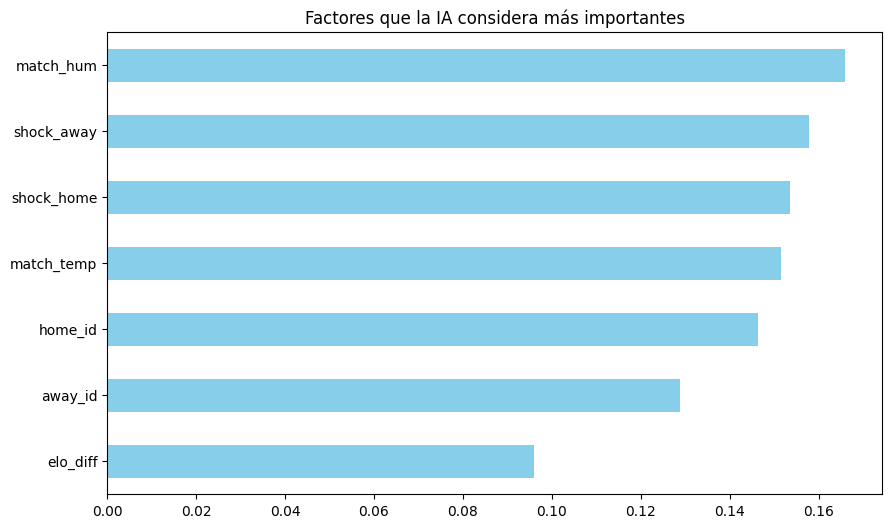

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("mundiales_clima_pro.csv")


def definir_ganador(row):
    if row['home_score'] > row['away_score']: return 0 # Home
    if row['away_score'] > row['home_score']: return 1 # Away
    return 2 # Draw

df['target'] = df.apply(definir_ganador, axis=1)

# Codificamos los nombres de los equipos
le = LabelEncoder()
todos_equipos = pd.concat([df['home_team'], df['away_team']]).unique()
le.fit(todos_equipos)
df['home_id'] = le.transform(df['home_team'])
df['away_id'] = le.transform(df['away_team'])

features = ['home_id', 'away_id', 'elo_diff', 'match_temp', 'match_hum', 'shock_home', 'shock_away']
X = df[features].fillna(0)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# El modelo entrena en milisegundos
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Precisión: {accuracy_score(y_test, y_pred) * 100:.2f}%")


plt.figure(figsize=(10,6))
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', color='skyblue')
plt.title("Factores que la IA considera más importantes")
plt.show()

## SIMULACIÓN MUNDIAL 2026 - FASE DE GRUPOS 